In [18]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")
from src.graphs import StaticGraph, DynamicGraph, ParallelEdgeGraph, NonDiagonalEdgeGraph
from qiskit.quantum_info import Statevector, Operator, state_fidelity
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


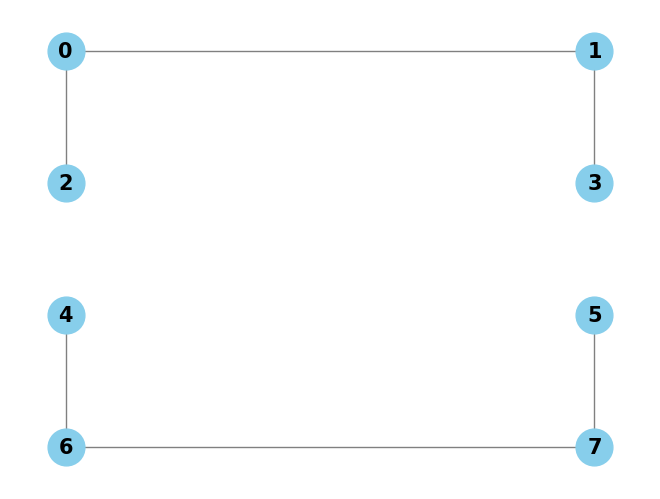

In [6]:
edges = {('000','010'),
         ('000','001'),
         ('001','011'),
         ('100','110'),
         ('110','111'),
         ('101','111')}

G = StaticGraph(edges)
G.draw()

In [25]:
from collections import defaultdict

# Create a dictionary to hold sets of edges with the same target
target_groups = defaultdict(set)

# Iterate over each edge in the graph
for e in G.edges:
    g = ParallelEdgeGraph({e})
    target_groups[g.target].add(e)


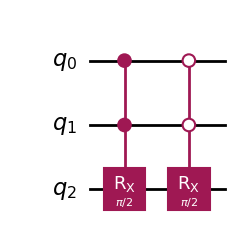

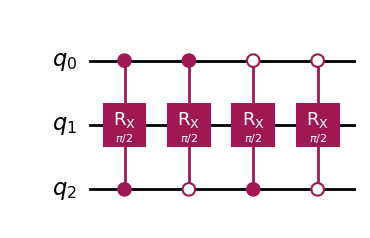

In [26]:
for target, edges in target_groups.items():
    non_diag = NonDiagonalEdgeGraph(edges)
    qc = non_diag.get_qc(simplified=True)
    display(qc.draw('mpl'))